In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *

# Multilayer Perceptrion (MLP)

## Model

In [3]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm == 'layer':
            self.normL = nn.LayerNorm(out_size)
        elif norm == 'batch':
            self.normL = nn.BatchNorm1d(out_size)
        elif norm == 'instance':
            self.normL = nn.InstanceNorm1d(out_size)
    
    def forward(self, x):
        x = self.fc(x)
        if self.norm:
            x = self.normL(x)
        x = self.act(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm == 'layer':
            self.normL = nn.LayerNorm(h_size[0])
        if norm == 'batch':
            self.normL = nn.BatchNorm1d(h_size[0])
        if norm == 'instance':
            self.normL = nn.InstanceNorm1d(h_size[0])
        self.dropout = nn.Dropout(0.25)
        self.hlayers = nn.ModuleList([
            MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.fcIN(x)
        if self.norm:
            x = self.normL(x)
        x = self.act(x)
        for layer in self.hlayers:
            x = layer(x)
        x = self.fcOUT(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")                                         # TODO: implement gpu

Using device: cpu


# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [4]:
DAT = DATA(load=True)

In [5]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [128]*3

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
n_epochs = 500

In [6]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
mlp1 = MLP(in_size, h_size, out_size, norm="layer").to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=30, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [8]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 0.6089573502540588
Epoch: 10 - Loss: 0.24830207228660583
Epoch: 20 - Loss: 0.09602335095405579
Epoch: 30 - Loss: 0.043562546372413635
Epoch: 40 - Loss: 0.028439074754714966
Epoch: 50 - Loss: 0.021260088309645653
Epoch: 60 - Loss: 0.017041917890310287
Epoch: 70 - Loss: 0.014573846012353897
Epoch: 80 - Loss: 0.01255284994840622
Epoch: 90 - Loss: 0.011489415541291237
Epoch: 100 - Loss: 0.009687673300504684
Epoch: 110 - Loss: 0.009269411675632
Epoch: 120 - Loss: 0.008845840580761433
Epoch: 130 - Loss: 0.007832394912838936
Epoch: 140 - Loss: 0.007435060106217861
Epoch: 150 - Loss: 0.007364553399384022
Epoch: 160 - Loss: 0.0066031767055392265
Epoch: 170 - Loss: 0.006793124135583639
Epoch: 180 - Loss: 0.00697334436699748
Epoch: 190 - Loss: 0.006250583101063967
Epoch: 200 - Loss: 0.005809936206787825
Epoch: 210 - Loss: 0.005452650599181652
Epoch: 220 - Loss: 0.005338692106306553
Epoch: 230 - Loss: 0.00547046447172761
Epoch: 240 - Loss: 0.006094216834753752
Epoch 00245: reducin

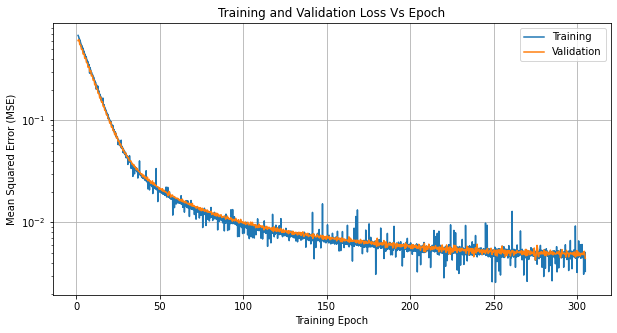

In [9]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [10]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [11]:
err = list(abs(sum(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(13, 81)

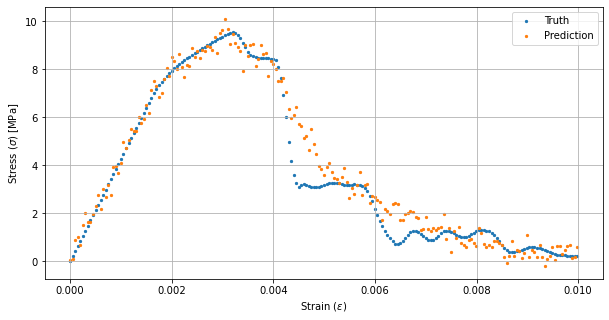

In [12]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=82)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [13]:
DAT1 = DATA(load=True, format=1)

In [14]:
DAT1.train_in1.shape, DAT1.dx_out1.shape

((357, 2), (3588, 357, 1))

In [15]:
in_size = DAT1.train_in1.shape[-1]
out_size = DAT1.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 10

In [16]:
trainDS1x = Dataset_(DAT1.train_in1, DAT1.dx_out1[0])
trainDS1y = Dataset_(DAT1.train_in1, DAT1.dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [18]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 2.089517831802368
Epoch: 10 - Loss: 1.8613141775131226
Best Epoch: 6, with loss 1.7997682094573975


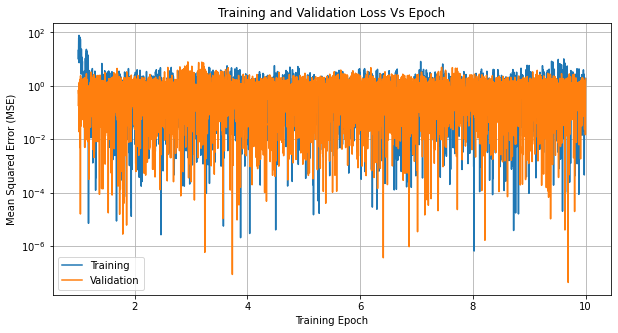

In [19]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [20]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - DAT1.dx_out1[0,:,0]), min(test_outputs[:,0] - DAT1.dx_out1[0,:,0])

(1.3642999093579387, -1.9570156624946549)

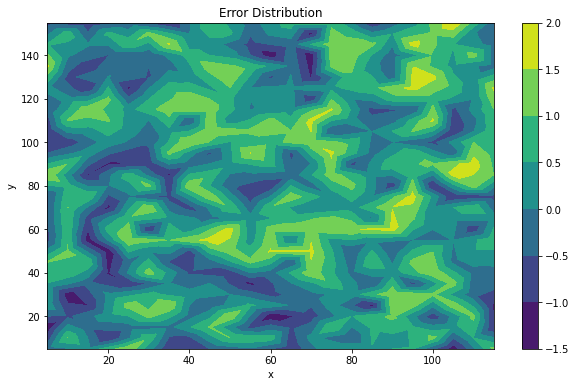

In [21]:
plot_Distribution(DAT1.train_in1, test_outputs[:,0], dx_out1=DAT1.dx_out1[0,:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [22]:
DAT2 = DATA(load=True, format=2)

In [23]:
DAT2.train_in2.shape, DAT2.dx_out2.shape

((2, 714), (3588, 2, 357))

In [24]:
in_size = DAT2.train_in2.shape[-1]
out_size = DAT2.dx_out2.shape[-1]
h_size = [2**10]

BATCH_SIZE = 8
LEARNING_RATE = 9e-4
n_epochs = 10000

In [25]:
trainDS1x = Dataset_(DAT2.train_in2, DAT2.dx_out2[0])
trainDS1y = Dataset_(DAT2.train_in2, DAT2.dy_out2[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
mlp3 = MLP(in_size, h_size, out_size).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [27]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 3704.636962890625
Epoch: 10 - Loss: 1286.436279296875
Epoch: 20 - Loss: 308.2671813964844
Epoch: 30 - Loss: 72.42858123779297
Epoch: 40 - Loss: 20.973405838012695
Epoch: 50 - Loss: 14.226984024047852
Epoch: 60 - Loss: 6.989189624786377
Epoch: 70 - Loss: 1.837530255317688
Epoch: 80 - Loss: 1.6300281286239624
Epoch: 90 - Loss: 0.390771746635437
Epoch: 100 - Loss: 0.21790878474712372
Epoch: 110 - Loss: 0.16365021467208862
Epoch: 120 - Loss: 0.09164002537727356
Epoch: 130 - Loss: 0.03879626467823982
Epoch: 140 - Loss: 0.018333934247493744
Epoch: 150 - Loss: 0.01799679920077324
Epoch: 160 - Loss: 0.013242155313491821
Epoch: 170 - Loss: 0.006169755477458239
Epoch: 180 - Loss: 0.006725280545651913
Epoch: 190 - Loss: 0.004730300512164831
Epoch: 200 - Loss: 0.014551772736012936
Epoch: 210 - Loss: 0.010235488414764404
Epoch 00214: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 220 - Loss: 0.0019158542854711413
Epoch: 230 - Loss: 0.0018909999635070562
Epoch: 240 - Loss: 

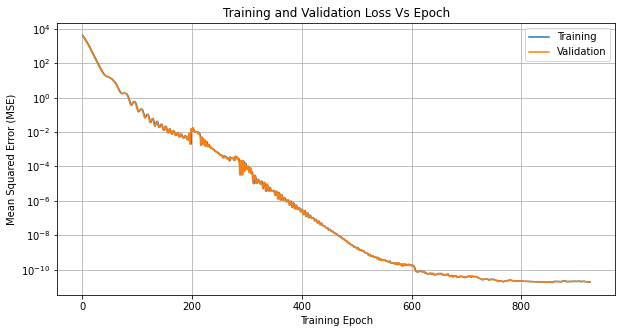

In [28]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [29]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - DAT2.dx_out2[0,0])), min(abs(test_outputs[0] - DAT2.dx_out2[0,0]))

(1.1928741457722936e-05, 1.7211920777526757e-09)

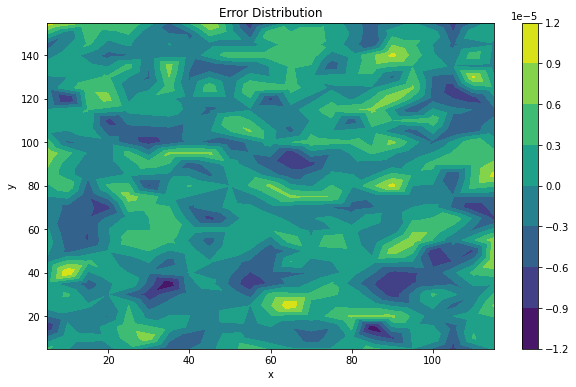

In [30]:
plot_Distribution(DAT2.train_in1, test_outputs[0], dx_out1=DAT2.dx_out2[0,0], typ="contour")

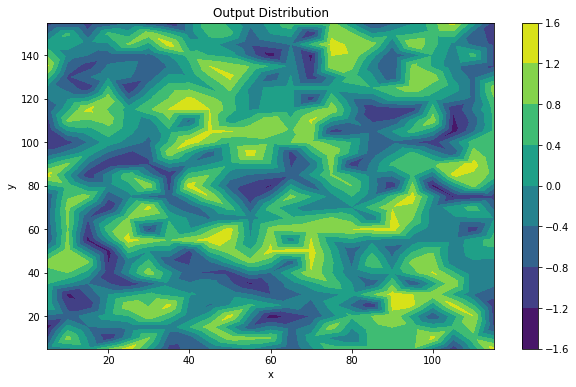

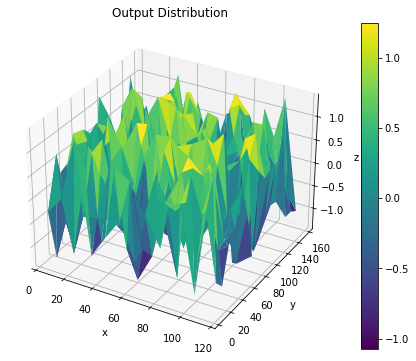

In [31]:
plot_Distribution(DAT2.train_in1, test_outputs[0], typ="both")

In [32]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\n")

fcIN.weight: torch.Size([1024, 714])
tensor([[ 0.0083,  0.0222,  0.0069,  ...,  0.0050,  0.0061, -0.0491],
        [ 0.0228, -0.0248, -0.0243,  ...,  0.0029, -0.0015,  0.0367],
        [-0.0141, -0.0490, -0.0143,  ..., -0.0404, -0.0015,  0.0101],
        ...,
        [ 0.0417,  0.0087,  0.0162,  ...,  0.0281, -0.0413, -0.0046],
        [-0.0645, -0.0017, -0.0314,  ...,  0.0499,  0.0208,  0.0343],
        [-0.0011,  0.0287, -0.0217,  ..., -0.0079, -0.0531,  0.0179]])

fcIN.bias: torch.Size([1024])
tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.0007,  0.0000, -0.0010])

fcOUT.weight: torch.Size([357, 1024])
tensor([[ 0.0329, -0.0319,  0.0176,  ..., -0.0337,  0.0680, -0.0638],
        [ 0.0746, -0.0418,  0.0295,  ...,  0.0076,  0.0555,  0.0194],
        [ 0.0293,  0.0871,  0.0230,  ...,  0.0406, -0.0046,  0.0081],
        ...,
        [ 0.0148, -0.0791, -0.0260,  ...,  0.0369,  0.0039,  0.0382],
        [-0.0602, -0.0339,  0.0489,  ..., -0.0065,  0.0355, -0.0530],
        [-0.0350,  0.0159, 